# Epsilon-Margin Profile-Level POSet

This notebook builds a profile-level POSet using an epsilon-margin dominance rule.

Unlike the epsilon-tolerant version, this approach does not allow a profile to be worse in any dimension. Epsilon is used only as a minimum advantage threshold.

A profile A dominates profile B if:

1. A is at least as good as B in every scaled variable.
2. A is better than B by more than epsilon in at least one scaled variable.

This preserves the partial-order structure and avoids cyclic dominance.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# ------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------
input_file = "data/processed/dataset_structural_indicators.csv"

country_col = "country"
year_col = "year"

analysis_year = 2019

# Hard-coded epsilon margin.
# Since variables are scaled to 0–1, 0.10 means:
# one profile must exceed another by >10 percentage points in at least one dimension,
# while being no worse in every other dimension.
selected_epsilon = 0.5

# Number of ordinal levels for creating profile codes
num_levels = 5

raw_variable_cols = [
    "Energy_Import_Dependency",
    "Public_Debt_pct_GDP",
    "R&D_Expenditure_pct_GDP",
    "Tertiary_Education_Attainment",
    "Gov_Score",
]


output_dir = Path("data/Processed/Profile_Epsilon_Margin_POSet")
output_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# ------------------------------------------------------
# LOAD AND FILTER DATASET
# ------------------------------------------------------

df_raw = pd.read_csv(input_file)

if country_col not in df_raw.columns:
    raise ValueError(f"Country column '{country_col}' not found.")

if year_col not in df_raw.columns:
    raise ValueError(f"Year column '{year_col}' not found.")

df_raw[year_col] = df_raw[year_col].astype(int)

df = df_raw[df_raw[year_col] == analysis_year].copy()

if df.empty:
    raise ValueError(f"No rows found for {year_col} = {analysis_year}")

df[country_col] = df[country_col].astype(str).str.strip()

print("Rows after filtering:", len(df))
print("Unique countries:", df[country_col].nunique())
print("Analysis year:", analysis_year)

df.head()

Rows after filtering: 37
Unique countries: 37
Analysis year: 2019


,year,country,R&D_Expenditure_pct_GDP,Gov_Score,Public_Debt_pct_GDP,Energy_Import_Dependency,Tertiary_Education_Attainment
18,2019,AUS,1.7899,83.0058,59.9838,0.0000,47.1300
42,2019,AUT,3.1441,82.3175,71.0000,74.4763,33.7738
66,2019,BEL,3.1515,82.1826,97.7000,90.9302,40.6701
90,2019,CAN,1.7558,84.7787,53.3623,0.0000,59.0203
114,2019,CHE,3.0856,85.7185,18.9543,55.4032,44.4125


In [4]:
# ------------------------------------------------------
# DIRECTION ALIGNMENT
# Higher must mean structurally better
# ------------------------------------------------------


ordering_variables = [
    "Energy_Import_Dependency", #negative-direction variable: higher is worse, so invert it
    "Public_Debt_pct_GDP", #negative-direction variable: higher is worse, so invert it
    "R&D_Expenditure_pct_GDP",
    "Tertiary_Education_Attainment",
    "Gov_Score",
]

missing_raw_cols = [col for col in ordering_variables if col not in df.columns]

if missing_raw_cols:
    raise ValueError(f"Missing raw variable columns: {missing_raw_cols}")

df_poset = df.copy()

# Negative-direction variables: higher is worse, so invert them
df_poset["Energy_Import_Dependency"] = (
    df_poset["Energy_Import_Dependency"].max(skipna=True) - df_poset["Energy_Import_Dependency"]
)

df_poset["Public_Debt_pct_GDP"] = (
    df_poset["Public_Debt_pct_GDP"].max(skipna=True) - df_poset["Public_Debt_pct_GDP"]
)

direction_metadata = pd.DataFrame([
    {
        "raw_variable": "Energy_Import_Dependency",
        "aligned_variable": "inflation_stability",
        "direction": "inverted",
        "interpretation": "lower inflation treated as better"
    },
    {
        "raw_variable": "Public_Debt_pct_GDP",
        "aligned_variable": "debt_capacity",
        "direction": "inverted",
        "interpretation": "lower debt treated as better"
    },
    {
        "raw_variable": "R&D_Expenditure_pct_GDP",
        "aligned_variable": "rd_intensity",
        "direction": "positive",
        "interpretation": "higher R&D intensity treated as better"
    },
    {
        "raw_variable": "Tertiary_Education_Attainment",
        "aligned_variable": "tertiary_education",
        "direction": "positive",
        "interpretation": "higher tertiary education treated as better"
    },
    {
        "raw_variable": "Gov_Score",
        "aligned_variable": "gov_effectiveness",
        "direction": "positive",
        "interpretation": "higher government effectiveness treated as better"
    }
])

df = df_poset.copy()

direction_metadata

,raw_variable,aligned_variable,direction,interpretation
0,Energy_Import_Dependency,inflation_stability,inverted,lower inflation treated as better
1,Public_Debt_pct_GDP,debt_capacity,inverted,lower debt treated as better
2,R&D_Expenditure_pct_GDP,rd_intensity,positive,higher R&D intensity treated as better
3,Tertiary_Education_Attainment,tertiary_education,positive,higher tertiary education treated as better
4,Gov_Score,gov_effectiveness,positive,higher government effectiveness treated as better


In [5]:
# ------------------------------------------------------
# VALIDATE INPUT STRUCTURE
# ------------------------------------------------------

missing_ordering_vars = [
    var for var in ordering_variables
    if var not in df.columns
]

if missing_ordering_vars:
    raise ValueError(f"Missing ordering variables: {missing_ordering_vars}")

duplicate_countries = df[df[country_col].duplicated()][country_col].tolist()

if duplicate_countries:
    raise ValueError(
        f"Duplicate countries found: {duplicate_countries}. "
        "Each country should appear only once for the selected analysis year."
    )

non_numeric_cols = [
    col for col in ordering_variables
    if not pd.api.types.is_numeric_dtype(df[col])
]

if non_numeric_cols:
    raise ValueError(f"These ordering variables are not numeric: {non_numeric_cols}")

missing_values = df[ordering_variables].isna().sum()

if missing_values.sum() > 0:
    print("Missing values found:")
    print(missing_values[missing_values > 0])
    raise ValueError("Please handle missing values before running POSet.")

print("Input validation passed.")
print(f"Countries: {df[country_col].nunique()}")
print(f"Ordering variables: {ordering_variables}")
print(f"Analysis year: {analysis_year}")

Input validation passed.
Countries: 37
Ordering variables: ['Energy_Import_Dependency', 'Public_Debt_pct_GDP', 'R&D_Expenditure_pct_GDP', 'Tertiary_Education_Attainment', 'Gov_Score']
Analysis year: 2019


In [6]:
# ------------------------------------------------------
# SCALE VARIABLES TO 0–1
# ------------------------------------------------------

scaled_variable_cols = []
scaling_rows = []

for var in ordering_variables:
    scaled_var = f"{var}_scaled"

    min_value = df[var].min(skipna=True)
    max_value = df[var].max(skipna=True)

    if pd.isna(min_value) or pd.isna(max_value):
        raise ValueError(f"Cannot scale {var}: missing min/max.")

    if max_value == min_value:
        raise ValueError(f"Cannot scale {var}: constant value across countries.")

    df[scaled_var] = (df[var] - min_value) / (max_value - min_value)

    scaled_variable_cols.append(scaled_var)

    scaling_rows.append({
        "variable": var,
        "scaled_variable": scaled_var,
        "min_value": min_value,
        "max_value": max_value
    })

scaling_metadata = pd.DataFrame(scaling_rows)

scaling_metadata

,variable,scaled_variable,min_value,max_value
0,Energy_Import_Dependency,Energy_Import_Dependency_scaled,0.0000,100.0000
1,Public_Debt_pct_GDP,Public_Debt_pct_GDP_scaled,0.0000,174.2000
2,R&D_Expenditure_pct_GDP,R&D_Expenditure_pct_GDP_scaled,0.3195,5.7912
3,Tertiary_Education_Attainment,Tertiary_Education_Attainment_scaled,18.2542,59.0203
4,Gov_Score,Gov_Score_scaled,40.9941,90.9756


In [7]:
# ------------------------------------------------------
# CREATE ORDINAL PROFILES
# ------------------------------------------------------

def create_ordinal_profiles(data, country_col, variable_cols, num_levels=5):
    """
    Converts scaled continuous variables into ordinal levels.

    Example with 5 levels:
    0 = weakest group
    4 = strongest group

    Then combines levels into a profile code.
    """

    profile_df = data[[country_col] + variable_cols].copy()

    level_cols = []

    for col in variable_cols:
        level_col = col.replace("_scaled", "_level")

        profile_df[level_col] = pd.qcut(
            profile_df[col].rank(method="first"),
            q=num_levels,
            labels=False
        ).astype(int)

        level_cols.append(level_col)

    profile_df["profile_code"] = (
        profile_df[level_cols]
        .astype(str)
        .agg("".join, axis=1)
    )

    return profile_df, level_cols


profile_df, profile_level_cols = create_ordinal_profiles(
    data=df,
    country_col=country_col,
    variable_cols=scaled_variable_cols,
    num_levels=num_levels
)

profile_df[[country_col, "profile_code"] + profile_level_cols].head()

,country,profile_code,Energy_Import_Dependency_level,Public_Debt_pct_GDP_level,R&D_Expenditure_pct_GDP_level,Tertiary_Education_Attainment_level,Gov_Score_level
18,AUS,42243,4,2,2,4,3
42,AUT,11413,1,1,4,1,3
66,BEL,00423,0,0,4,2,3
90,CAN,42243,4,2,2,4,3
114,CHE,24434,2,4,4,3,4


In [8]:
# ------------------------------------------------------
# COLLAPSE COUNTRIES INTO UNIQUE PROFILES
# ------------------------------------------------------

unique_profiles_df = (
    profile_df[["profile_code"] + profile_level_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)

profile_country_map = (
    profile_df
    .groupby("profile_code")[country_col]
    .apply(lambda x: ", ".join(sorted(x)))
    .reset_index()
    .rename(columns={country_col: "countries"})
)

profile_country_count = (
    profile_df
    .groupby("profile_code")[country_col]
    .nunique()
    .reset_index()
    .rename(columns={country_col: "num_countries"})
)

print("Countries:", profile_df[country_col].nunique())
print("Unique profiles:", unique_profiles_df["profile_code"].nunique())

profile_country_map.head()

Countries: 37
Unique profiles: 36


,profile_code,countries
0,00101,ITA
1,00110,GRC
2,00112,PRT
3,00122,ESP
4,00423,BEL


In [9]:
# ------------------------------------------------------
# PROFILE REPRESENTATIVES
# ------------------------------------------------------
# Each profile is represented by the mean scaled values
# of countries belonging to that profile.

profile_representatives_df = (
    profile_df
    .groupby("profile_code")[scaled_variable_cols]
    .mean()
    .reset_index()
)

profile_representatives_df = profile_representatives_df.merge(
    unique_profiles_df,
    on="profile_code",
    how="left"
)

profile_representatives_df = profile_representatives_df.merge(
    profile_country_count,
    on="profile_code",
    how="left"
)

profile_representatives_df.head()

,profile_code,Energy_Import_Dependency_scaled,Public_Debt_pct_GDP_scaled,R&D_Expenditure_pct_GDP_scaled,Tertiary_Education_Attainment_scaled,Gov_Score_scaled,Energy_Import_Dependency_level,Public_Debt_pct_GDP_level,R&D_Expenditure_pct_GDP_level,Tertiary_Education_Attainment_level,Gov_Score_level,num_countries
0,00101,0.177720,0.283008,0.207632,0.035355,0.630333,0,0,1,0,1,1
1,00110,0.125010,0.000000,0.172323,0.334501,0.574355,0,0,1,1,0,1
2,00112,0.156435,0.385189,0.196539,0.199727,0.741568,0,0,1,1,2,1
3,00122,0.170859,0.490815,0.168613,0.499013,0.700029,0,0,1,2,2,1
4,00423,0.090698,0.490815,0.517572,0.549866,0.824075,0,0,4,2,3,1


In [10]:
# ------------------------------------------------------
# EPSILON-MARGIN DOMINANCE BETWEEN PROFILES
# ------------------------------------------------------

def build_epsilon_margin_profile_dominance_matrix(
    profile_representatives_df,
    profile_col,
    value_cols,
    epsilon_k
):
    """
    Builds an epsilon-margin dominance matrix over unique profiles.

    Profile A dominates Profile B if:

    1. A is at least as good as B in every dimension:
       A_j >= B_j for all j

    2. A is better than B by more than epsilon in at least one dimension:
       A_j > B_j + epsilon for at least one j

    This preserves partial-order validity because no trade-off compensation is allowed.
    """

    profiles = profile_representatives_df[profile_col].astype(str).tolist()
    values = profile_representatives_df[value_cols].values

    n = len(profiles)
    dominance_matrix = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            a = values[i]
            b = values[j]

            not_worse_all = np.all(a >= b)
            better_by_margin = np.any(a > b + epsilon_k)

            if not_worse_all and better_by_margin:
                dominance_matrix[i, j] = 1

    dominance_df = pd.DataFrame(
        dominance_matrix,
        index=profiles,
        columns=profiles
    )

    return dominance_df


profile_dominance_df = build_epsilon_margin_profile_dominance_matrix(
    profile_representatives_df=profile_representatives_df,
    profile_col="profile_code",
    value_cols=scaled_variable_cols,
    epsilon_k=selected_epsilon
)

profile_dominance_df

,00101,00110,00112,00122,00423,02441,04031,04144,11200,11413,...,33434,34201,34224,40441,41000,41333,42243,42334,43000,44232
00101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00110,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00112,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00122,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00423,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
02441,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
04031,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
04144,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11200,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11413,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# ------------------------------------------------------
# COMPARABILITY / INCOMPARABILITY DIAGNOSTICS
# ------------------------------------------------------

def build_comparability_matrix(dominance_df):
    comparability_values = dominance_df.values + dominance_df.values.T
    comparability_values = (comparability_values > 0).astype(int)
    np.fill_diagonal(comparability_values, 0)

    return pd.DataFrame(
        comparability_values,
        index=dominance_df.index,
        columns=dominance_df.columns
    )


def build_incomparability_matrix(dominance_df):
    comparability_df = build_comparability_matrix(dominance_df)

    incomparability_values = 1 - comparability_df.values
    np.fill_diagonal(incomparability_values, 0)

    return pd.DataFrame(
        incomparability_values,
        index=dominance_df.index,
        columns=dominance_df.columns
    )


def get_profile_summary(dominance_df):
    dominates_count = dominance_df.sum(axis=1)
    dominated_by_count = dominance_df.sum(axis=0)

    n = len(dominance_df)

    incomparable_with_count = (
        (n - 1) - dominates_count - dominated_by_count
    )

    summary_df = pd.DataFrame({
        "profile_code": dominance_df.index,
        "dominates_count": dominates_count.values,
        "dominated_by_count": dominated_by_count.values,
        "incomparable_with_count": incomparable_with_count.values
    })

    summary_df["is_pareto_frontier"] = summary_df["dominated_by_count"] == 0

    return summary_df.sort_values(
        ["is_pareto_frontier", "dominates_count"],
        ascending=[False, False]
    )


def get_overall_comparability_summary(dominance_df):
    n = len(dominance_df)

    total_unordered_pairs = n * (n - 1) / 2
    comparable_pairs = dominance_df.values.sum()
    incomparable_pairs = total_unordered_pairs - comparable_pairs

    return {
        "epsilon_k": selected_epsilon,
        "num_profiles": n,
        "total_unordered_pairs": int(total_unordered_pairs),
        "comparable_pairs": int(comparable_pairs),
        "incomparable_pairs": int(incomparable_pairs),
        "comparability_ratio": round(comparable_pairs / total_unordered_pairs, 3) if total_unordered_pairs > 0 else 0,
        "incomparability_ratio": round(incomparable_pairs / total_unordered_pairs, 3) if total_unordered_pairs > 0 else 0
    }


profile_comparability_df = build_comparability_matrix(profile_dominance_df)
profile_incomparability_df = build_incomparability_matrix(profile_dominance_df)

profile_summary_df = get_profile_summary(profile_dominance_df)
overall_comparability_summary = get_overall_comparability_summary(profile_dominance_df)

overall_comparability_summary

{'epsilon_k': 0.5,
 'num_profiles': 36,
 'total_unordered_pairs': 630,
 'comparable_pairs': 58,
 'incomparable_pairs': 572,
 'comparability_ratio': 0.092,
 'incomparability_ratio': 0.908}

In [12]:
profile_summary_df

,profile_code,dominates_count,dominated_by_count,incomparable_with_count,is_pareto_frontier
35,44232,10,0,25,True
26,33434,8,0,27,True
33,42334,7,0,28,True
32,42243,6,0,29,True
21,24434,5,0,30,True
28,34224,5,0,30,True
31,41333,4,0,31,True
25,33324,3,0,32,True
13,13324,2,0,33,True
23,31334,2,0,33,True


In [13]:
# ------------------------------------------------------
# HASSE GRAPH / TRANSITIVE REDUCTION
# ------------------------------------------------------

def build_hasse_graph_from_dominance(dominance_df):
    """
    Builds full dominance graph and Hasse graph.

    With epsilon-margin dominance, the graph should remain acyclic.
    The DAG check is still retained as a safety check.
    """

    G_full = nx.DiGraph()

    for node in dominance_df.index:
        G_full.add_node(node)

    for source in dominance_df.index:
        for target in dominance_df.columns:
            if dominance_df.loc[source, target] == 1:
                G_full.add_edge(source, target)

    is_dag = nx.is_directed_acyclic_graph(G_full)

    diagnostics = {
        "is_dag": is_dag,
        "cycle_example": None
    }

    if not is_dag:
        try:
            diagnostics["cycle_example"] = nx.find_cycle(G_full)
        except Exception:
            diagnostics["cycle_example"] = "Cycle exists but could not be extracted."

        return G_full, None, None, diagnostics

    G_hasse = nx.transitive_reduction(G_full)

    hasse_edges_df = pd.DataFrame(
        list(G_hasse.edges()),
        columns=["from_profile", "to_profile"]
    )

    return G_full, G_hasse, hasse_edges_df, diagnostics


profile_G_full, profile_G_hasse, profile_hasse_edges_df, dag_diagnostics = (
    build_hasse_graph_from_dominance(profile_dominance_df)
)

dag_diagnostics

{'is_dag': True, 'cycle_example': None}

In [14]:
# ------------------------------------------------------
# VALIDATE ACYCLICITY
# ------------------------------------------------------

if not dag_diagnostics["is_dag"]:
    raise ValueError(
        f"Unexpected cycle found with epsilon-margin rule. "
        f"Cycle example: {dag_diagnostics['cycle_example']}"
    )

print(f"Selected epsilon margin = {selected_epsilon} produces a valid acyclic POSet.")

profile_hasse_edges_df.head()

Selected epsilon margin = 0.5 produces a valid acyclic POSet.


,from_profile,to_profile
0,11413,00110
1,13324,00101
2,13324,00110
3,21211,00110
4,24434,11200


In [15]:
# ------------------------------------------------------
# POSET LAYERS, HEIGHT, WIDTH
# ------------------------------------------------------

def get_poset_layers(G_hasse):
    layer_rows = []

    for layer_number, generation in enumerate(
        nx.topological_generations(G_hasse),
        start=1
    ):
        for profile in sorted(generation):
            layer_rows.append({
                "poset_layer": layer_number,
                "profile_code": profile
            })

    return pd.DataFrame(layer_rows)


def get_poset_height(G_hasse):
    if len(G_hasse.nodes()) == 0:
        return 0

    return len(nx.dag_longest_path(G_hasse))


def get_poset_width_from_dominance(dominance_df):
    profiles = list(dominance_df.index)
    n = len(profiles)

    B = nx.DiGraph()

    left_nodes = [f"L_{p}" for p in profiles]
    right_nodes = [f"R_{p}" for p in profiles]

    B.add_nodes_from(left_nodes, bipartite=0)
    B.add_nodes_from(right_nodes, bipartite=1)

    for source in profiles:
        for target in profiles:
            if dominance_df.loc[source, target] == 1:
                B.add_edge(f"L_{source}", f"R_{target}")

    matching = nx.algorithms.bipartite.maximum_matching(
        B,
        top_nodes=left_nodes
    )

    matching_size = len(matching) // 2

    return n - matching_size


profile_layers_df = get_poset_layers(profile_G_hasse)

poset_height = get_poset_height(profile_G_hasse)
poset_width = get_poset_width_from_dominance(profile_dominance_df)

print(f"Unique profiles: {len(profile_dominance_df)}")
print(f"POSet height: {poset_height}")
print(f"POSet width: {poset_width}")

profile_layers_df.head()

Unique profiles: 36
POSet height: 3
POSet width: 26


,poset_layer,profile_code
0,1,02441
1,1,04031
2,1,04144
3,1,11413
4,1,11440


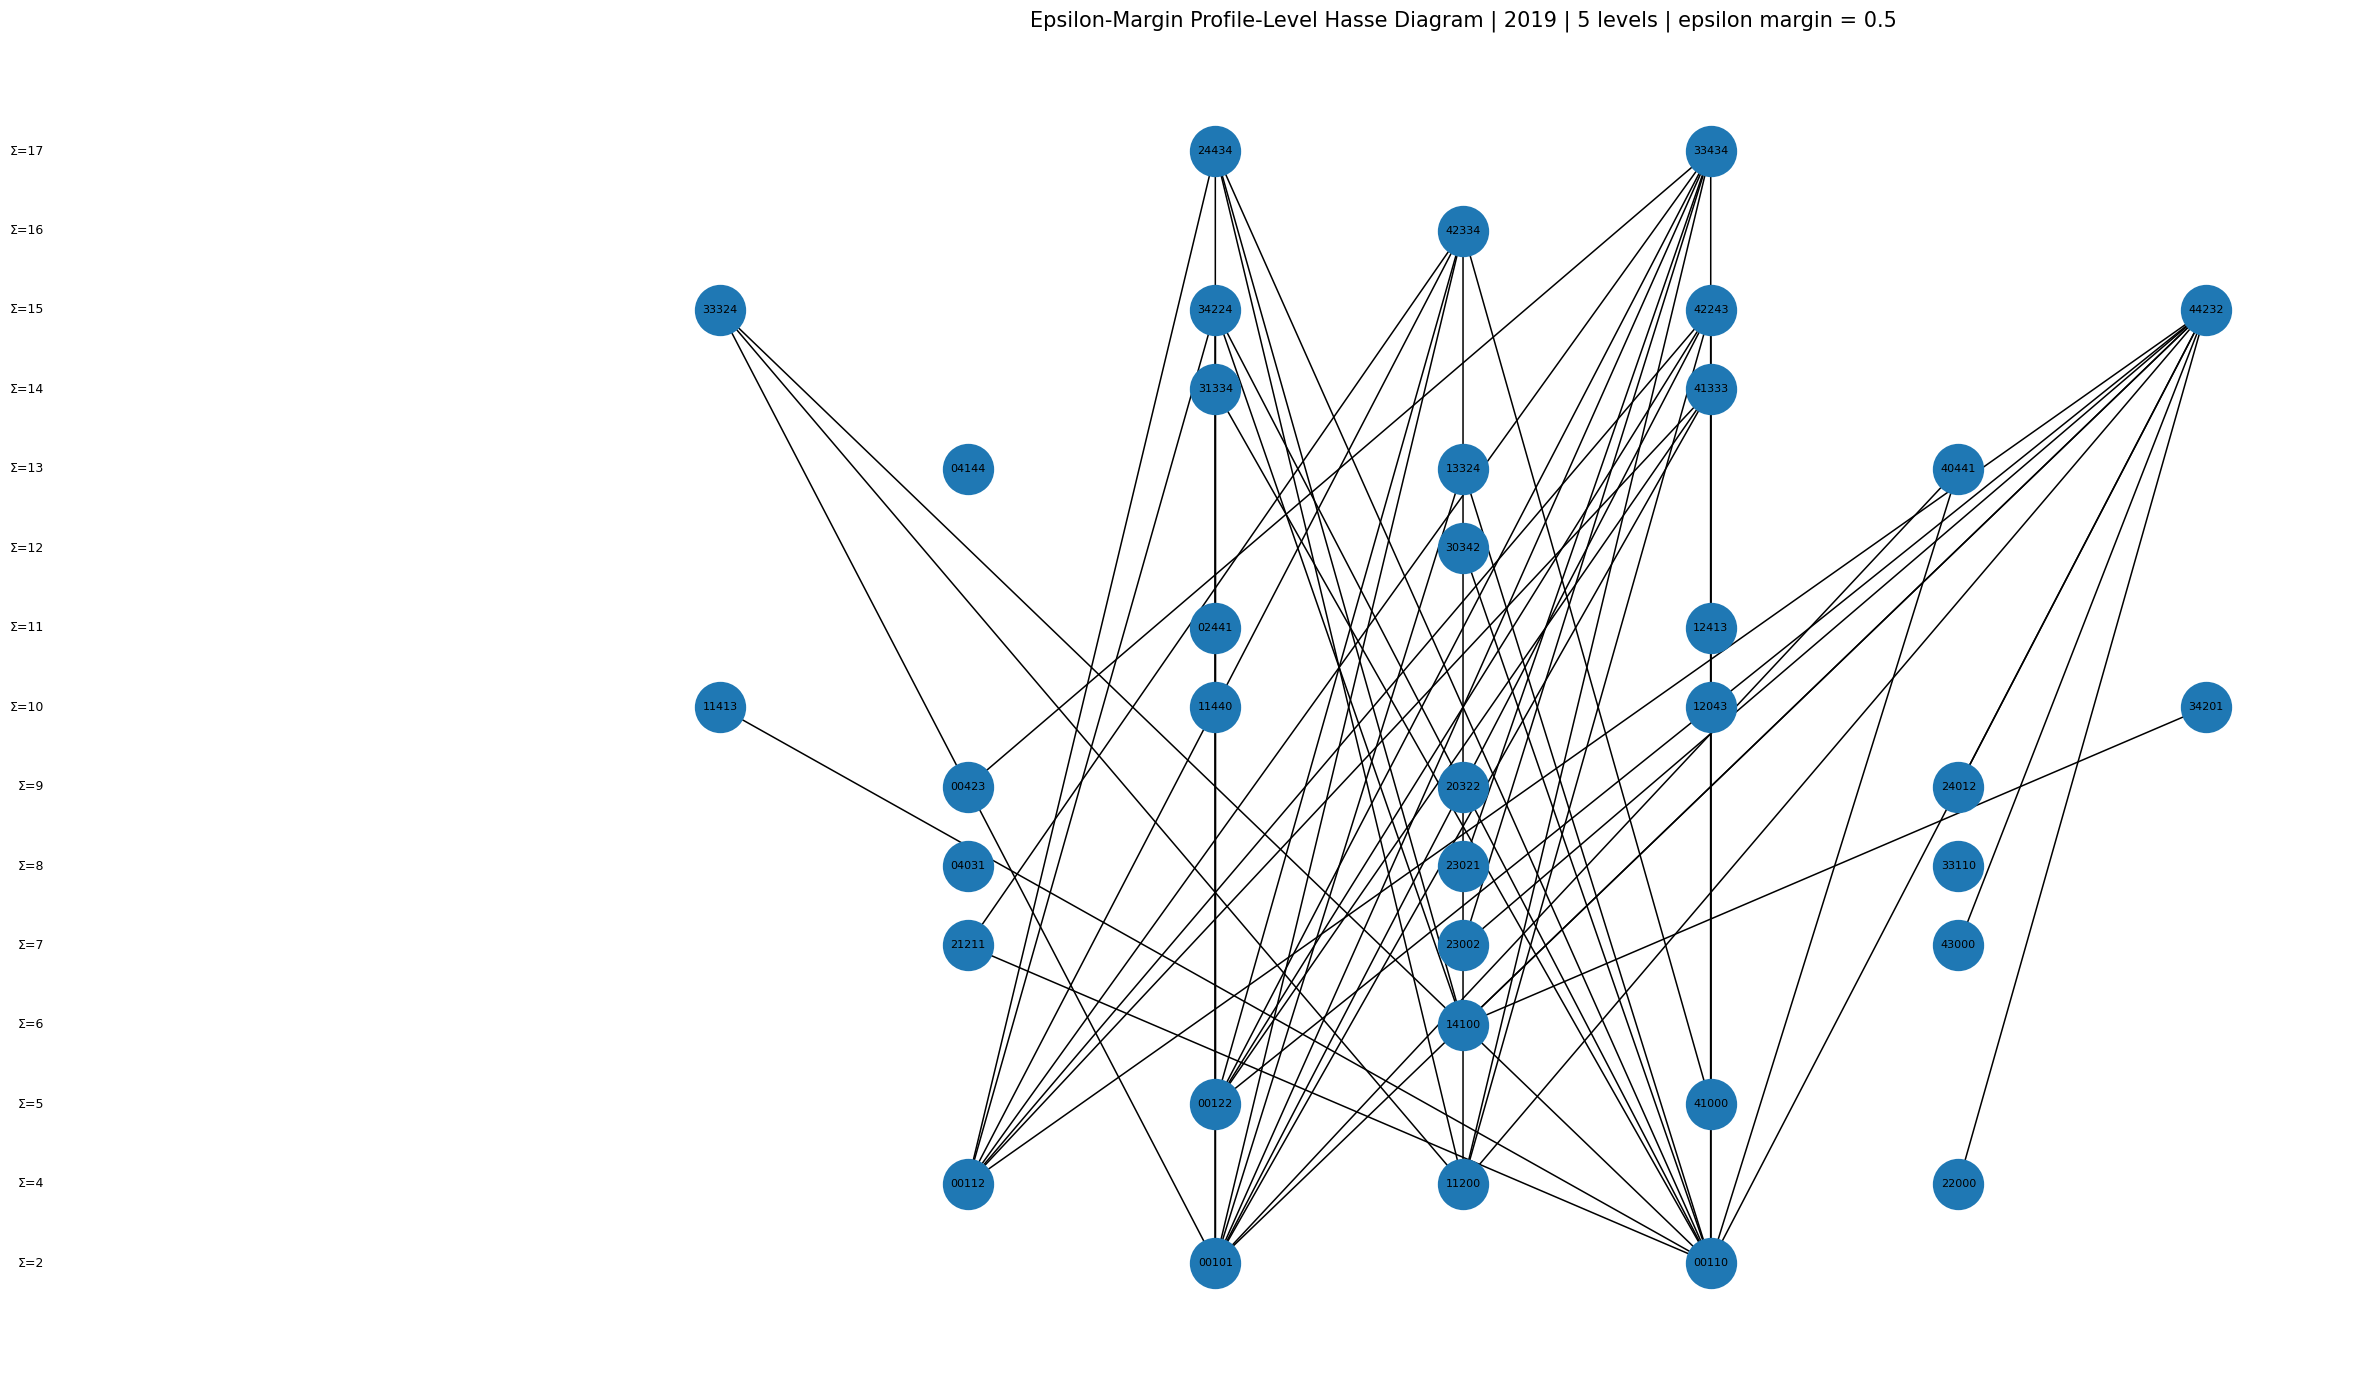

In [16]:
# ------------------------------------------------------
# FATTORE-STYLE LAYERED HASSE DIAGRAM
# ------------------------------------------------------

def profile_digit_sum(profile_code):
    return sum(int(ch) for ch in str(profile_code))


plot_profiles_df = profile_representatives_df[["profile_code"]].copy()
plot_profiles_df["level_sum"] = plot_profiles_df["profile_code"].apply(profile_digit_sum)

level_groups = (
    plot_profiles_df
    .groupby("level_sum")["profile_code"]
    .apply(list)
    .to_dict()
)

sorted_levels = sorted(level_groups.keys(), reverse=True)

pos = {}

vertical_gap = 2.0
horizontal_gap = 2.2

for y_idx, level in enumerate(sorted_levels):
    nodes_in_level = sorted(level_groups[level])
    n = len(nodes_in_level)

    x_positions = np.linspace(
        -(n - 1) / 2,
        (n - 1) / 2,
        n
    ) * horizontal_gap

    for x, node in zip(x_positions, nodes_in_level):
        pos[node] = (x, -y_idx * vertical_gap)

plt.figure(figsize=(24, 14))

nx.draw_networkx_edges(
    profile_G_hasse,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=14,
    width=1.1
)

nx.draw_networkx_nodes(
    profile_G_hasse,
    pos,
    node_size=1250,
    linewidths=1.6
)

nx.draw_networkx_labels(
    profile_G_hasse,
    pos,
    font_size=8
)

min_x = min(x for x, y in pos.values())

for y_idx, level in enumerate(sorted_levels):
    plt.text(
        min_x - 3,
        -y_idx * vertical_gap,
        f"Σ={level}",
        fontsize=9,
        ha="right",
        va="center"
    )

plt.title(
    f"Epsilon-Margin Profile-Level Hasse Diagram | {analysis_year} | "
    f"{num_levels} levels | epsilon margin = {selected_epsilon}",
    fontsize=15
)

plt.axis("off")
plt.tight_layout()
plt.show()

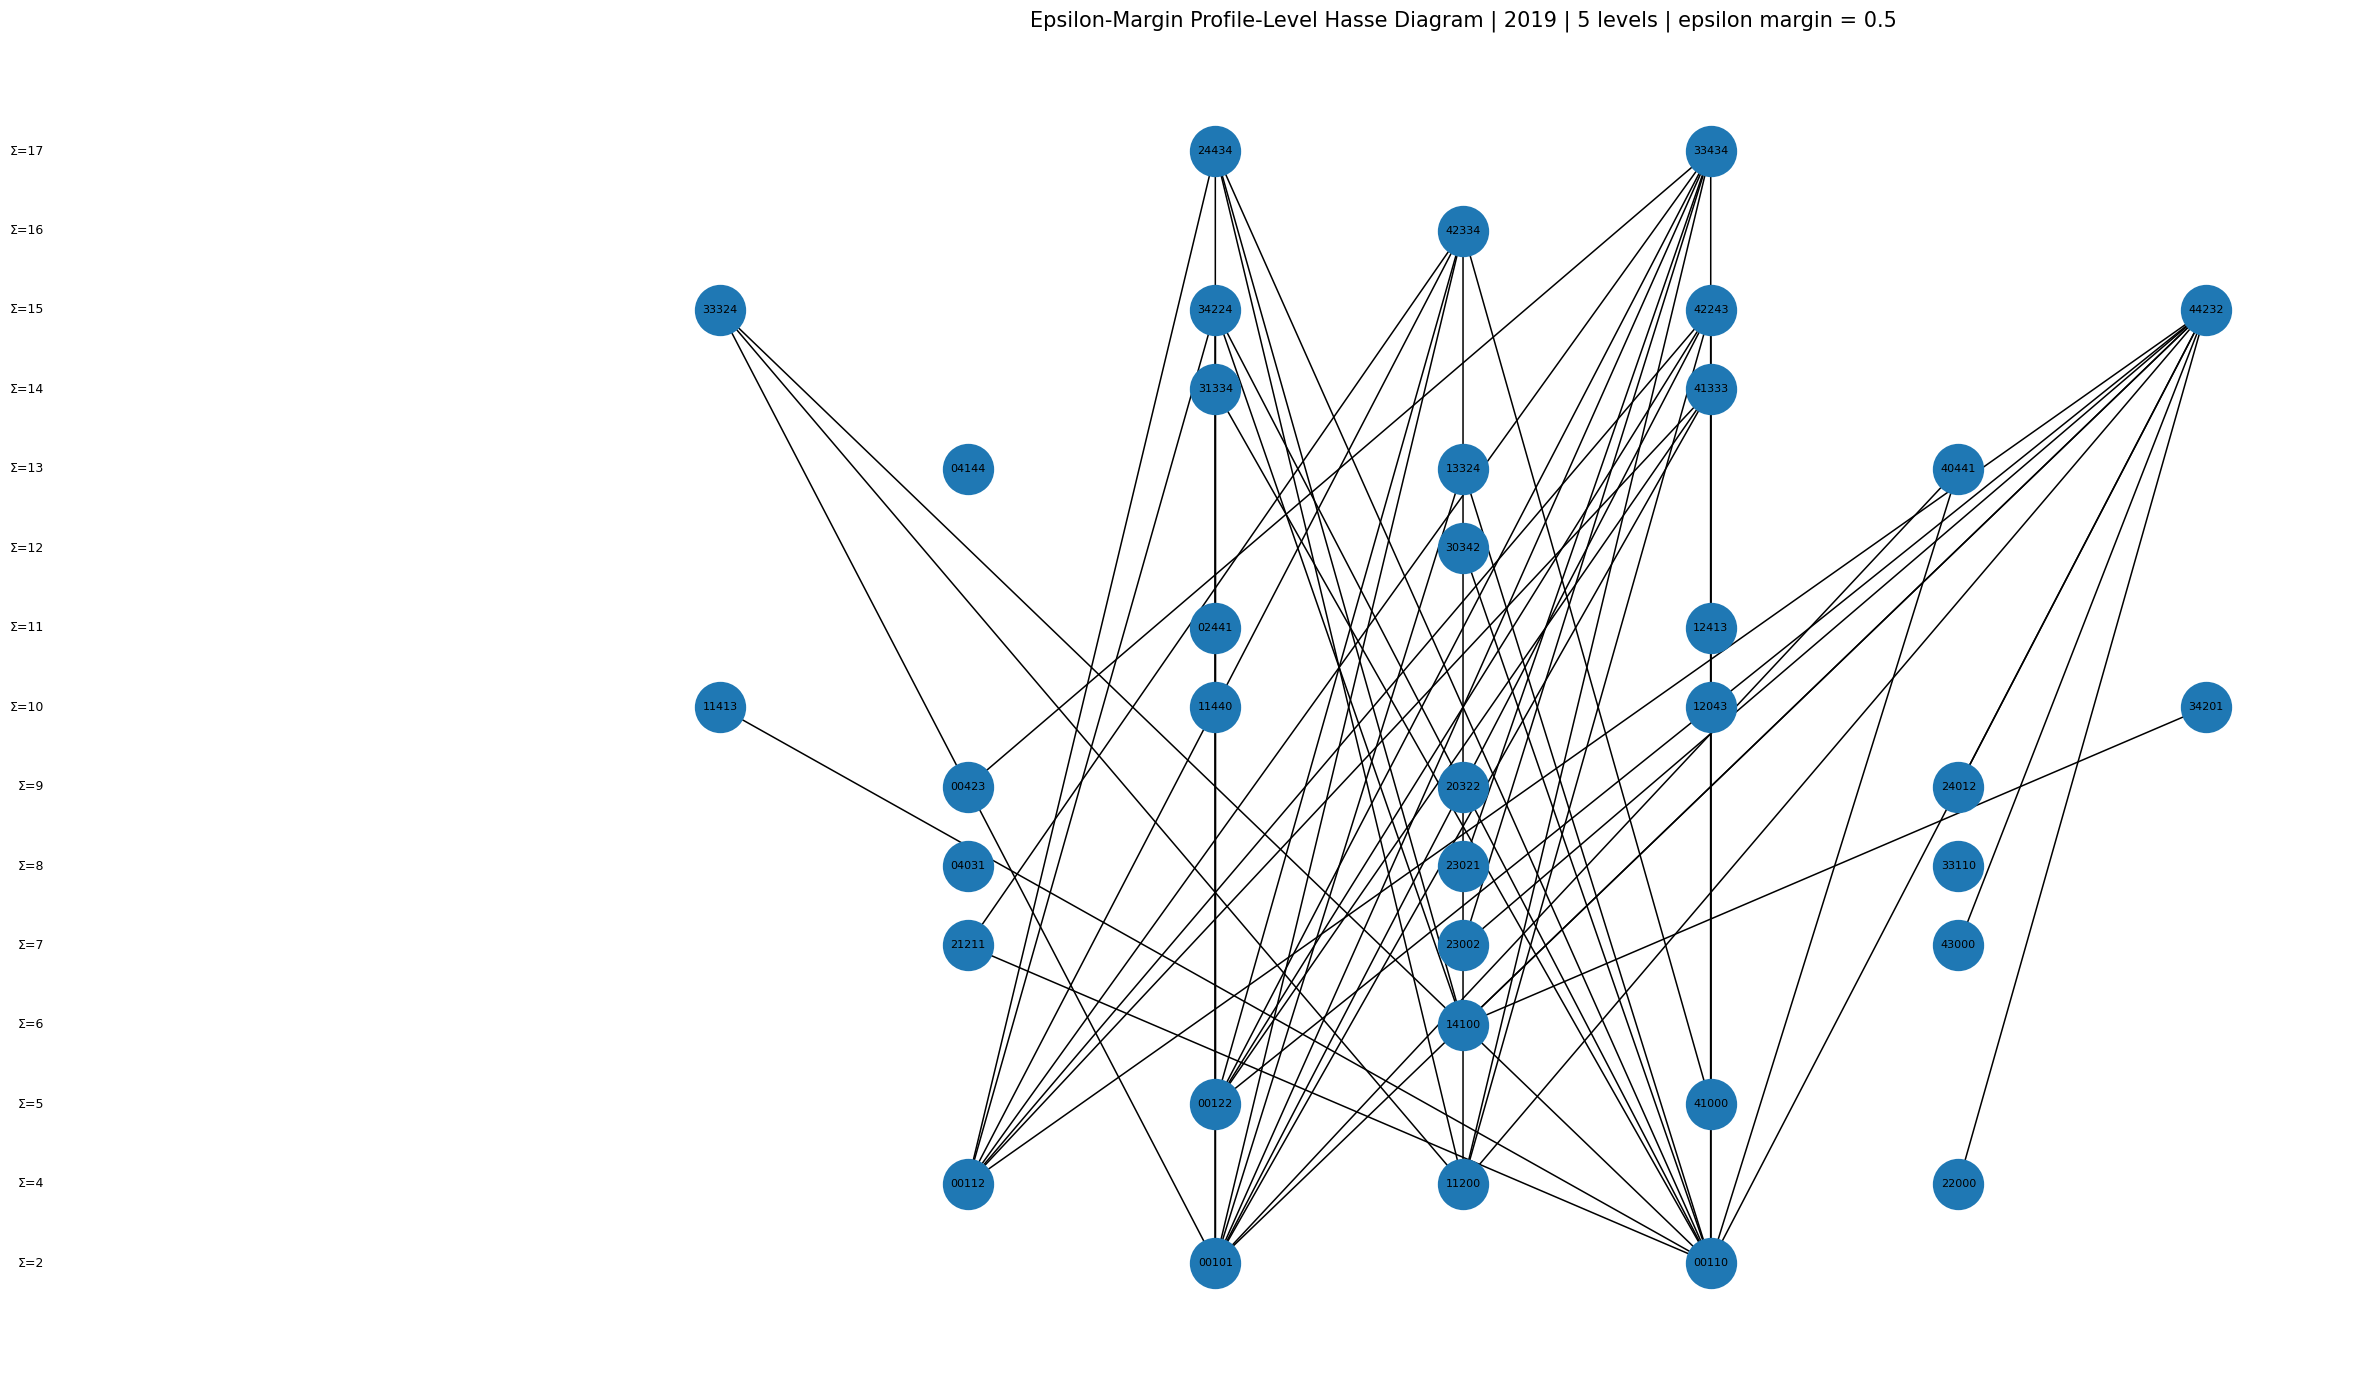

Saved diagram to: Data\Processed\Profile_Epsilon_Margin_POSet\profile_epsilon_margin_poset_2019_5levels_eps_0_5_hasse_diagram.png


In [17]:
# ------------------------------------------------------
# SAVE HASSE DIAGRAM
# ------------------------------------------------------

output_prefix = (
    f"profile_epsilon_margin_poset_{analysis_year}_"
    f"{num_levels}levels_eps_{str(selected_epsilon).replace('.', '_')}"
)

diagram_path = output_dir / f"{output_prefix}_hasse_diagram.png"

plt.figure(figsize=(24, 14))

nx.draw_networkx_edges(
    profile_G_hasse,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=14,
    width=1.1
)

nx.draw_networkx_nodes(
    profile_G_hasse,
    pos,
    node_size=1250,
    linewidths=1.6
)

nx.draw_networkx_labels(
    profile_G_hasse,
    pos,
    font_size=8
)

for y_idx, level in enumerate(sorted_levels):
    plt.text(
        min_x - 3,
        -y_idx * vertical_gap,
        f"Σ={level}",
        fontsize=9,
        ha="right",
        va="center"
    )

plt.title(
    f"Epsilon-Margin Profile-Level Hasse Diagram | {analysis_year} | "
    f"{num_levels} levels | epsilon margin = {selected_epsilon}",
    fontsize=15
)

plt.axis("off")
plt.tight_layout()

plt.savefig(diagram_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved diagram to: {diagram_path}")

In [18]:
# ------------------------------------------------------
# PAIRWISE COMPARABILITY TABLE
# ------------------------------------------------------

def classify_profile_pair(profile_a, profile_b, G_hasse):
    profile_a = str(profile_a)
    profile_b = str(profile_b)

    # Guard: isolated nodes may be absent from G_hasse after transitive reduction
    a_in = G_hasse.has_node(profile_a)
    b_in = G_hasse.has_node(profile_b)

    if a_in and b_in and nx.has_path(G_hasse, profile_a, profile_b):
        return f"{profile_a} dominates {profile_b}"
    elif a_in and b_in and nx.has_path(G_hasse, profile_b, profile_a):
        return f"{profile_b} dominates {profile_a}"
    else:
        return "incomparable"


profiles = sorted(profile_dominance_df.index.astype(str).tolist())

pair_rows = []

for i in range(len(profiles)):
    for j in range(i + 1, len(profiles)):
        profile_a = profiles[i]
        profile_b = profiles[j]

        pair_rows.append({
            "profile_a": profile_a,
            "profile_b": profile_b,
            "relationship": classify_profile_pair(
                profile_a,
                profile_b,
                profile_G_hasse
            )
        })

profile_pairwise_comparability_df = pd.DataFrame(pair_rows)

profile_pairwise_comparability_df.head(20)

,profile_a,profile_b,relationship
0,00101,00110,incomparable
1,00101,00112,incomparable
2,00101,00122,incomparable
3,00101,00423,incomparable
4,00101,02441,incomparable
5,00101,04031,incomparable
6,00101,04144,incomparable
7,00101,11200,incomparable
8,00101,11413,incomparable
9,00101,11440,incomparable


In [19]:
# ------------------------------------------------------
# EPSILON-MARGIN SENSITIVITY SCAN
# ------------------------------------------------------

epsilon_margin_grid = [0, 0.025, 0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.25, 0.30,0.40,0.5,0.75,1.0]

epsilon_margin_rows = []

for eps in epsilon_margin_grid:
    dominance_test_df = build_epsilon_margin_profile_dominance_matrix(
        profile_representatives_df=profile_representatives_df,
        profile_col="profile_code",
        value_cols=scaled_variable_cols,
        epsilon_k=eps
    )

    G_test = nx.DiGraph()

    for node in dominance_test_df.index:
        G_test.add_node(node)

    for source in dominance_test_df.index:
        for target in dominance_test_df.columns:
            if dominance_test_df.loc[source, target] == 1:
                G_test.add_edge(source, target)

    is_dag = nx.is_directed_acyclic_graph(G_test)

    n = len(dominance_test_df)
    total_unordered_pairs = n * (n - 1) / 2
    comparable_pairs = dominance_test_df.values.sum()

    profile_summary_test = get_profile_summary(dominance_test_df)
    pareto_profiles = (
        profile_summary_test
        .query("is_pareto_frontier == True")["profile_code"]
        .tolist()
    )

    epsilon_margin_rows.append({
        "epsilon_margin": eps,
        "is_valid_poset_dag": is_dag,
        "dominance_relations": int(comparable_pairs),
        "comparability_ratio": round(comparable_pairs / total_unordered_pairs, 3) if total_unordered_pairs > 0 else 0,
        "num_pareto_profiles": len(pareto_profiles),
        "pareto_profiles": ", ".join(pareto_profiles)
    })

epsilon_margin_sensitivity_df = pd.DataFrame(epsilon_margin_rows)

epsilon_margin_sensitivity_df

,epsilon_margin,is_valid_poset_dag,dominance_relations,comparability_ratio,num_pareto_profiles,pareto_profiles
0,0.000,True,95,0.151,17,"33434, 44232, 33324, 24434, 34224, 42334, 3133..."
1,0.025,True,95,0.151,17,"33434, 44232, 33324, 24434, 34224, 42334, 3133..."
2,0.050,True,95,0.151,17,"33434, 44232, 33324, 24434, 34224, 42334, 3133..."
3,0.075,True,95,0.151,17,"33434, 44232, 33324, 24434, 34224, 42334, 3133..."
4,0.100,True,95,0.151,17,"33434, 44232, 33324, 24434, 34224, 42334, 3133..."
5,0.125,True,95,0.151,17,"33434, 44232, 33324, 24434, 34224, 42334, 3133..."
6,0.150,True,95,0.151,17,"33434, 44232, 33324, 24434, 34224, 42334, 3133..."
7,0.200,True,95,0.151,17,"33434, 44232, 33324, 24434, 34224, 42334, 3133..."
8,0.250,True,94,0.149,17,"33434, 44232, 33324, 24434, 34224, 42334, 4224..."
9,0.300,True,89,0.141,17,"33434, 44232, 24434, 33324, 34224, 42334, 4224..."


In [20]:
# Export outputs (cleaner)
exports = {
    "country_profiles": (profile_df, False),  # country column already present; no row-index needed
    "unique_profiles": (unique_profiles_df, True),
    "profile_country_map": (profile_country_map, True),
    "profile_representatives": (profile_representatives_df, True),
    "dominance_matrix": (profile_dominance_df, False),  # original had no index=False
    "comparability_matrix": (profile_comparability_df, False),
    "incomparability_matrix": (profile_incomparability_df, False),
    "profile_summary": (profile_summary_df, True),
    "hasse_edges": (profile_hasse_edges_df, True),
    "layers": (profile_layers_df, True),
    "pairwise_comparability": (profile_pairwise_comparability_df, True),
    "epsilon_margin_sensitivity": (epsilon_margin_sensitivity_df, True),
    "direction_metadata": (direction_metadata, True),
    "scaling_metadata": (scaling_metadata, True),
}

for name, (df_obj, use_index) in exports.items():
    df_obj.to_csv(output_dir / f"{output_prefix}_{name}.csv", index=use_index)

run_metadata = pd.DataFrame([{
    "analysis_year": analysis_year,
    "num_levels": num_levels,
    "selected_epsilon_margin": selected_epsilon,
    "num_countries": df[country_col].nunique(),
    "num_unique_profiles": len(profile_dominance_df),
    "poset_height": poset_height,
    "poset_width": poset_width,
    "is_dag": dag_diagnostics["is_dag"],
    "comparability_ratio": overall_comparability_summary["comparability_ratio"],
    "incomparability_ratio": overall_comparability_summary["incomparability_ratio"],
}])

run_metadata.to_csv(output_dir / f"{output_prefix}_run_metadata.csv", index=False)

print("All epsilon-margin profile POSet outputs exported successfully.")
print(f"Output folder: {output_dir}")


All epsilon-margin profile POSet outputs exported successfully.
Output folder: Data\Processed\Profile_Epsilon_Margin_POSet


## Interpretation Guide

### Profile code

A profile code represents a country's ordinal position across the selected variables.

Example:

`432104`

means:

- variable 1 = level 4
- variable 2 = level 3
- variable 3 = level 2
- variable 4 = level 1
- variable 5 = level 0
- variable 6 = level 4

### Epsilon-margin dominance

This notebook uses epsilon as a minimum dominance margin.

Profile A dominates Profile B if:

1. A is at least as good as B in every scaled variable.
2. A is better than B by more than epsilon in at least one scaled variable.

This avoids the cyclic dominance problem that can occur when epsilon is used as a tolerance.

### Comparability

Two profiles are comparable if one dominates the other through a directed path in the Hasse diagram.

### Incomparability

Two profiles are incomparable if there is no directed path between them.

### Hasse diagram

The Hasse diagram shows direct dominance relations after transitive reduction.

A downward path means comparability.

No path means incomparability.

### Sensitivity scan

As epsilon margin increases, dominance becomes stricter. Therefore, dominance relations and comparability should usually decrease or stay the same.